# <center> Customer Segmentation of an Online Retail Store

<details>
<summary><b>Описание проекта</b></summary>

## Бизнес-задача

Компания стремится лучше понимать поведение клиентов интернет-магазина и перейти от массового маркетинга к персонализированным стратегиям взаимодействия.

Основная цель проекта — сегментировать клиентов на основе истории покупок, определить ценность каждого сегмента и подготовить основу для:
- персонализированного маркетинга;
- retention-стратегий;
- customer analytics;
- рекомендательных систем.

Проект реализован в production-style формате с использованием GPU-ускорения и RAPIDS ecosystem.

---

## Техническая задача

Необходимо построить ML-систему сегментации клиентов на основе транзакционных данных интернет-магазина.

Проект включает:
- очистку и preprocessing данных;
- feature engineering;
- GPU-кластеризацию;
- сравнение нескольких clustering algorithms;
- визуализацию сегментов;
- inference pipeline для новых клиентов.

---

## Используемый стек

### GPU / RAPIDS
- NVIDIA RTX 3090
- RAPIDS cuDF
- RAPIDS cuML
- CuPy

### Clustering
- RAPIDS KMeans
- RAPIDS DBSCAN
- RAPIDS HDBSCAN

### ML / Production Pipeline
- sklearn Pipeline
- StandardScaler

### Visualization
- UMAP
- matplotlib
- seaborn
- plotly

---

## Этапы проекта

### 1. Data Cleaning

Реализовано:
- обработка пропусков;
- удаление дубликатов;
- обработка возвратов (`Quantity > 0`);
- удаление нулевых цен (`UnitPrice > 0`);
- удаление специальных транзакций;
- создание признака `TotalPrice`.

Для специальных транзакций удаляются только служебные коды:
- POST
- D
- M
- BANK CHARGES
- DOT
- CRUK

---

### 2. Exploratory Data Analysis (EDA)

Проведен анализ:
- стран;
- выручки;
- monthly revenue;
- активности клиентов;
- заказов по времени;
- топ-клиентов.

---

### 3. Feature Engineering

### RFM-признаки
- Recency
- Frequency
- Monetary

### Дополнительные признаки
- AvgBasketSize
- UniqueProducts

Дополнительные признаки тестировались экспериментально, однако классические RFM-признаки показали лучшую эффективность кластеризации.

---

### 4. Outlier Handling

Реализовано удаление:
- top 5% Frequency;
- top 5% Monetary.

---

### 5. Final Production Pipeline

После сравнения нескольких preprocessing-подходов финальной моделью выбран baseline KMeans с классическим preprocessing.

Используется production-style pipeline:

```python
Pipeline([
    ("log_transform", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(
        n_clusters=4,
        random_state=42
    ))
])
```

Pipeline:
- централизует preprocessing и inference;
- улучшает reproducibility;
- упрощает deployment;
- объединяет preprocessing и модель в единый production artifact.

Эксперименты с расширенным feature engineering не улучшили качество кластеризации и не были включены в финальную модель. Log-transform (log1p) применяется в финальном pipeline как часть preprocessing.

---

### 6. GPU Clustering

Сравниваются несколько алгоритмов кластеризации:

- RAPIDS KMeans
- RAPIDS DBSCAN
- RAPIDS HDBSCAN

Используется:
- GPU acceleration;
- RAPIDS cuML;
- CuPy;
- cuDF.

---

### 7. Visualization

Реализованы:
- UMAP 2D visualization;
- cluster visualization;
- comparison of clustering algorithms;
- customer analytics charts.

UMAP-визуализация построена для:
- KMeans;
- DBSCAN;
- HDBSCAN.

---

### 8. Model Evaluation

Используются:
- silhouette score;
- algorithm comparison;
- baseline vs extended features comparison.

Evaluation выполняется на GPU через:

```python
cython_silhouette_score
```

---

### 9. Inference Pipeline

Реализована inference-функция:

```python
predict_customer_segment(...)
```

Inference pipeline:
- загружает final production pipeline;
- выполняет preprocessing;
- предсказывает сегмент нового клиента.

---

### 10. Model Artifacts

Сохраняются:
- `final_pipeline.pkl`
- `rfm_clusters.csv`

---

## Итог проекта

В результате построена GPU-ускоренная ML-система сегментации клиентов с:
- RAPIDS clustering;
- production pipeline;
- inference layer;
- model artifacts;
- UMAP visualization;
- сравнением нескольких clustering algorithms.

Финальный production pipeline объединяет preprocessing и кластеризацию в единый reusable artifact, пригодный для inference и deployment.

Проект демонстрирует production-oriented подход к Customer Segmentation и GPU Data Science.

</details>

In [90]:
# стандартная библиотека
import os
import warnings
# работа с данными
import joblib
import numpy as np
import pandas as pd
# GPU / RAPIDS
import cupy as cp
import cudf
import cuml
from cuml.cluster import DBSCAN, HDBSCAN, KMeans
from cuml.manifold import UMAP
# preprocessing и метрики
from cuml.metrics.cluster.silhouette_score import cython_silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, StandardScaler
# визуализация
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objs as go
import seaborn as sns
from plotly.subplots import make_subplots
# утилиты notebook
from IPython.display import HTML, display
# настройки notebook
warnings.filterwarnings("ignore")
plt.rcParams["patch.force_edgecolor"] = True
print("GPU READY !!!")

GPU READY !!!


## Data Overview and Initial Audit

На первом этапе необходимо изучить структуру данных, проверить качество датасета и подготовить признаки для дальнейшего анализа и кластеризации клиентов.

В этом разделе:
- изучим структуру данных
- проверим типы признаков
- найдем пропуски и дубликаты
- исследуем страны и клиентов
- выполним базовую предобработку

In [91]:
data = pd.read_csv("../data/raw/data.csv",encoding="ISO-8859-1",dtype={"CustomerID": str, "InvoiceNo": str},parse_dates=["InvoiceDate"],)

In [92]:
print(f"Shape: {data.shape}")
data.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [93]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 33.1+ MB


In [94]:
data.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829,541909
unique,25900,4070,4223,NaN,NaN,NaN,4372,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,17841,United Kingdom
freq,1114,2313,2369,NaN,NaN,NaN,7983,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,NaN,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,NaN,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,NaN,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,NaN,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,NaN,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,NaN,NaN


In [95]:
data.isna().sum().sort_values(ascending=False)

CustomerID     135080
Description      1454
InvoiceNo           0
StockCode           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

In [96]:
print(f"Duplicates: {data.duplicated().sum()}")

Duplicates: 5268


In [97]:
print(f"Unique customers: {data['CustomerID'].nunique()}")

Unique customers: 4372


In [98]:
print(f"Countries: {data['Country'].nunique()}")
data['Country'].value_counts().head(10)

Countries: 38


Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [99]:
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])
print(f"Date interval {data['InvoiceDate'].dt.date.min()} to {data['InvoiceDate'].dt.date.max()}")

Date interval 2010-12-01 to 2011-12-09


## Initial observations

После первичного анализа данных удалось выявить несколько важных особенностей датасета:

- датасет содержит более 540 тысяч транзакций
- данные охватывают период с декабря 2010 по декабрь 2011
- большинство заказов совершены из United Kingdom
- присутствуют пропуски в CustomerID и Description
- обнаружены отрицательные значения Quantity и UnitPrice
- присутствуют выбросы с очень большими значениями количества товаров и стоимости
- данные содержат возвраты товаров и специальные транзакции

Перед построением модели кластеризации необходимо выполнить очистку и предобработку данных.

## Data Cleaning

Подготовка транзакций для дальнейшего анализа и кластеризации клиентов.

In [100]:
print(f"Before cleaning: {data.shape}")
data = data.dropna(subset=["CustomerID"])
data = data.drop_duplicates()
print(f"After cleaning: {data.shape}")

Before cleaning: (541909, 8)


After cleaning: (401604, 8)


In [101]:
data.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

## Remove Returns

Удаляем возвраты и отмененные транзакции.

In [102]:
print(f"Before returns removing: {data.shape}")
data = data[data["Quantity"] > 0]
print(f"After returns removing: {data.shape}")

Before returns removing: (401604, 8)
After returns removing: (392732, 8)


In [103]:
data["Quantity"].describe()

count    392732.000000
mean         13.153718
std         181.588420
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

## Remove Zero Prices

Удаляем товары с нулевой стоимостью.

In [104]:
print(f"Before zero price removing: {data.shape}")
data = data[data["UnitPrice"] > 0]
print(f"After zero price removing: {data.shape}")

Before zero price removing: (392732, 8)
After zero price removing: (392692, 8)


In [105]:
data["UnitPrice"].describe()

count    392692.000000
mean          3.125914
std          22.241836
min           0.001000
25%           1.250000
50%           1.950000
75%           3.750000
max        8142.750000
Name: UnitPrice, dtype: float64

## Remove Special Transactions

Удаляем специальные транзакции и сервисные операции.

In [106]:
print(f"Before special transactions removing: {data.shape}")
# список служебных кодов
special_codes = ["POST", "D", "M", "BANK CHARGES", "DOT", "CRUK"]

# удаляем только спецтранзакции
data = data[~data["StockCode"].isin(special_codes)]
print(f"After special transactions removing: {data.shape}")

Before special transactions removing: (392692, 8)
After special transactions removing: (391286, 8)


In [107]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


## Create TotalPrice Feature

Создаем признак общей стоимости покупки.

In [108]:
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]
data[["Quantity", "UnitPrice", "TotalPrice"]].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [109]:
data["TotalPrice"].describe()

count    391286.000000
mean         22.346605
std         310.878881
min           0.001000
25%           4.950000
50%          11.900000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64

## Create Datetime Features

Создаем временные признаки для анализа сезонности и поведения клиентов.

In [110]:
data["Year"] = data["InvoiceDate"].dt.year
data["Month"] = data["InvoiceDate"].dt.month
data["Day"] = data["InvoiceDate"].dt.day
data["Hour"] = data["InvoiceDate"].dt.hour
data["Weekday"] = data["InvoiceDate"].dt.day_name()
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday


In [111]:
data[["InvoiceDate", "Month", "Hour", "Weekday"]].head()

,InvoiceDate,Month,Hour,Weekday
0,2010-12-01 08:26:00,12,8,Wednesday
1,2010-12-01 08:26:00,12,8,Wednesday
2,2010-12-01 08:26:00,12,8,Wednesday
3,2010-12-01 08:26:00,12,8,Wednesday
4,2010-12-01 08:26:00,12,8,Wednesday


## Data Cleaning Summary

На этапе предобработки данных были выполнены основные шаги очистки транзакций.

Было удалено:
- транзакции без CustomerID
- дубликаты
- возвраты товаров
- товары с нулевой стоимостью
- специальные сервисные транзакции

Также был создан новый признак:
- TotalPrice — общая стоимость покупки

Дополнительно были сформированы временные признаки:
- Year
- Month
- Day
- Hour
- Weekday

После очистки датасет стал более пригодным для дальнейшего анализа поведения клиентов и построения модели кластеризации.

## EDA

## Top countries by orders

Анализ стран с наибольшим количеством транзакций.

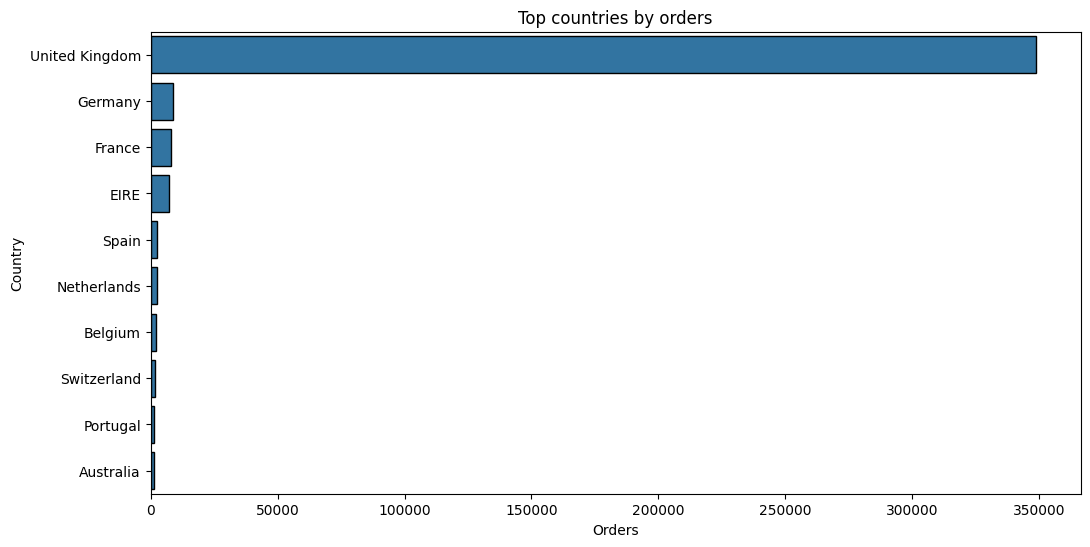

In [112]:
top_countries = data["Country"].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top countries by orders")
plt.xlabel("Orders")
plt.ylabel("Country")
plt.show()

Большая часть транзакций приходится на United Kingdom. Остальные страны представлены значительно слабее.

Это говорит о сильной географической концентрации клиентов и потенциальном смещении распределения данных в сторону британского рынка.

## Revenue by Country

Страны с наибольшей выручкой.

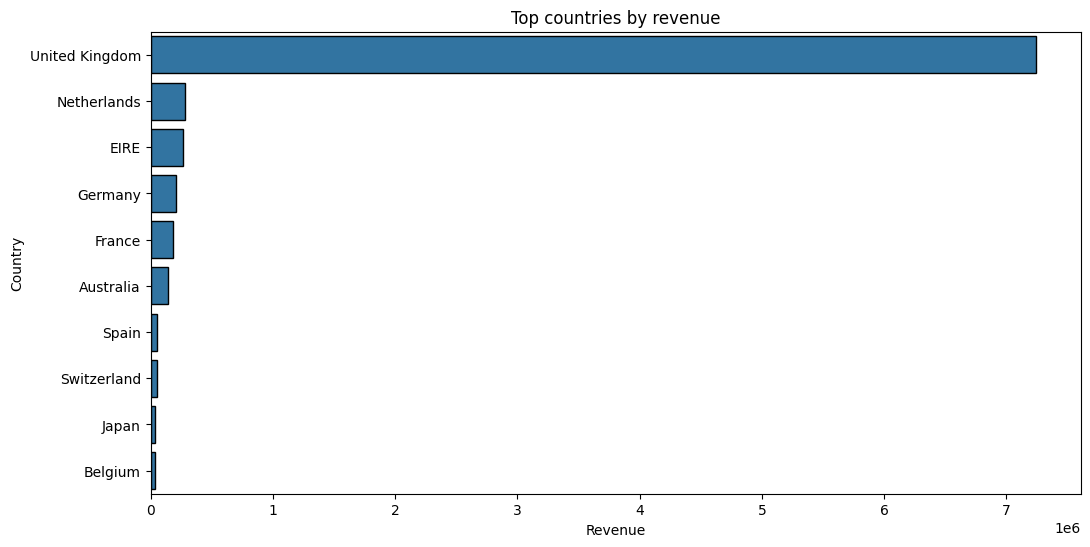

In [113]:
country_revenue = data.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=country_revenue.values, y=country_revenue.index)
plt.title("Top countries by revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()

United Kingdom остается абсолютным лидером по выручке.

При этом некоторые страны, например Netherlands, имеют относительно небольшое количество заказов, но высокую суммарную выручку. Это может говорить о более крупных и дорогих покупках.

## Orders by Hour

Распределение заказов по времени суток.

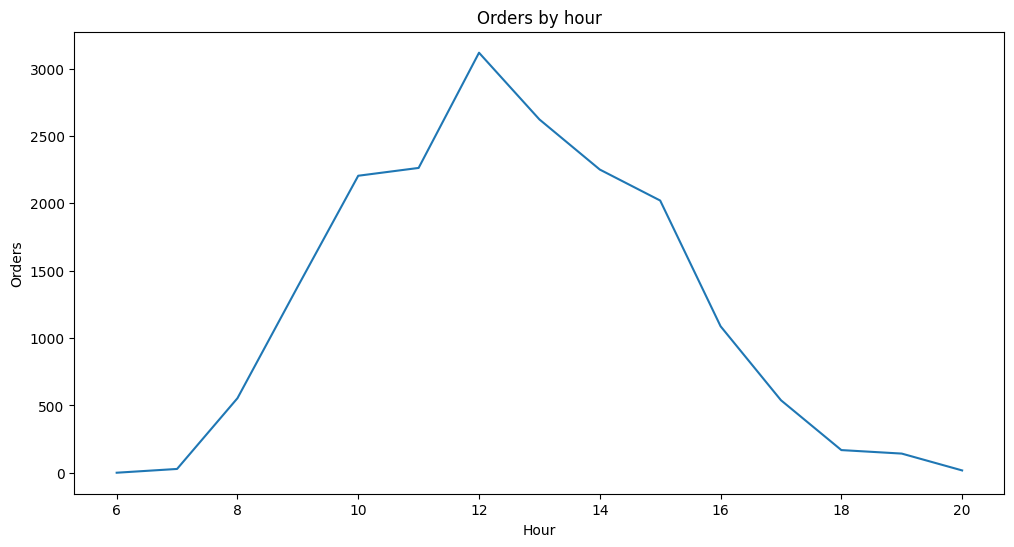

In [114]:
hour_orders = data.groupby("Hour")["InvoiceNo"].nunique()
plt.figure(figsize=(12, 6))
sns.lineplot(x=hour_orders.index, y=hour_orders.values)
plt.title("Orders by hour")
plt.xlabel("Hour")
plt.ylabel("Orders")
plt.show()

Основная активность клиентов наблюдается в дневное время.

Пик количества заказов приходится примерно на 12:00–13:00. После 16:00 активность начинает быстро снижаться.

Такое распределение характерно для business-oriented клиентов и оптовых покупателей.

## Monthly Revenue
Анализ сезонности продаж по месяцам.

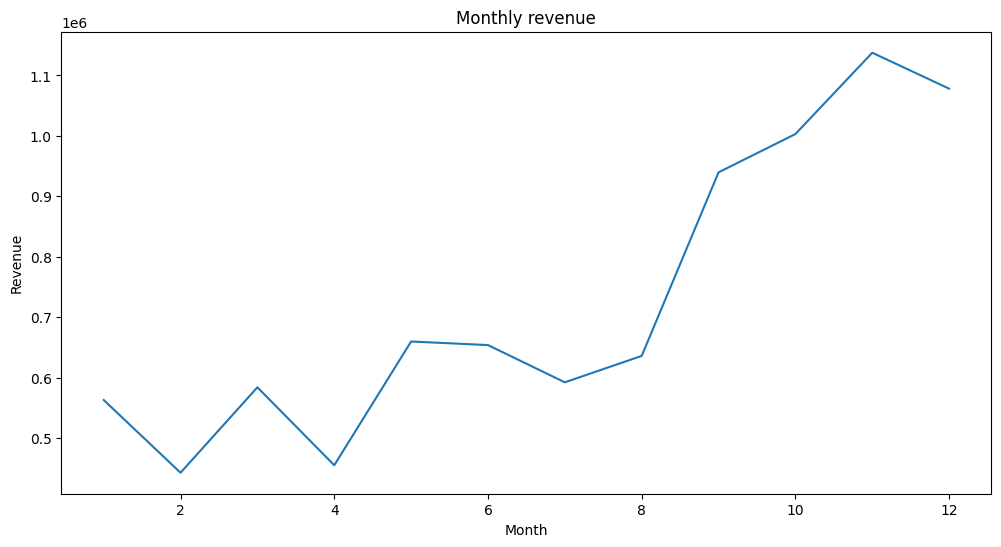

In [115]:
monthly_revenue = data.groupby("Month")["TotalPrice"].sum()
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values)
plt.title("Monthly revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

Во второй половине года наблюдается выраженный рост выручки.

Наиболее сильный рост начинается с сентября, а максимальная выручка достигается в ноябре. Вероятно, это связано с сезонными распродажами и предновогодним периодом.

Небольшое снижение в декабре связано с тем, что данные доступны только до 9 декабря 2011 года.

## Weekday Revenue
Анализ продаж по дням недели.

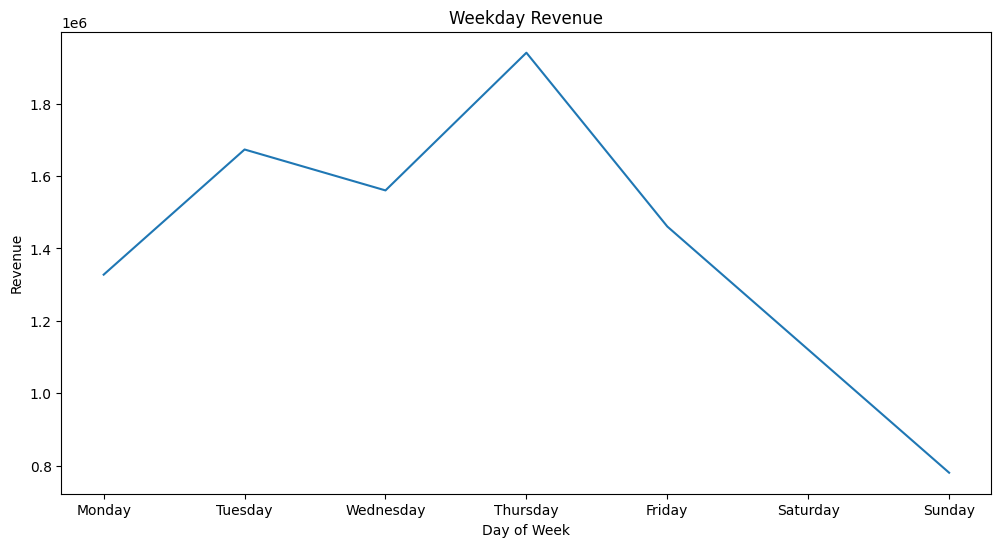

In [116]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_revenue = data.groupby("Weekday")["TotalPrice"].sum().reindex(weekday_order)

plt.figure(figsize=(12, 6))
sns.lineplot(x=weekday_revenue.index, y=weekday_revenue.values)
plt.title("Weekday Revenue")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.show()


## Top Customers by Revenue

Анализ клиентов с наибольшей суммой покупок.

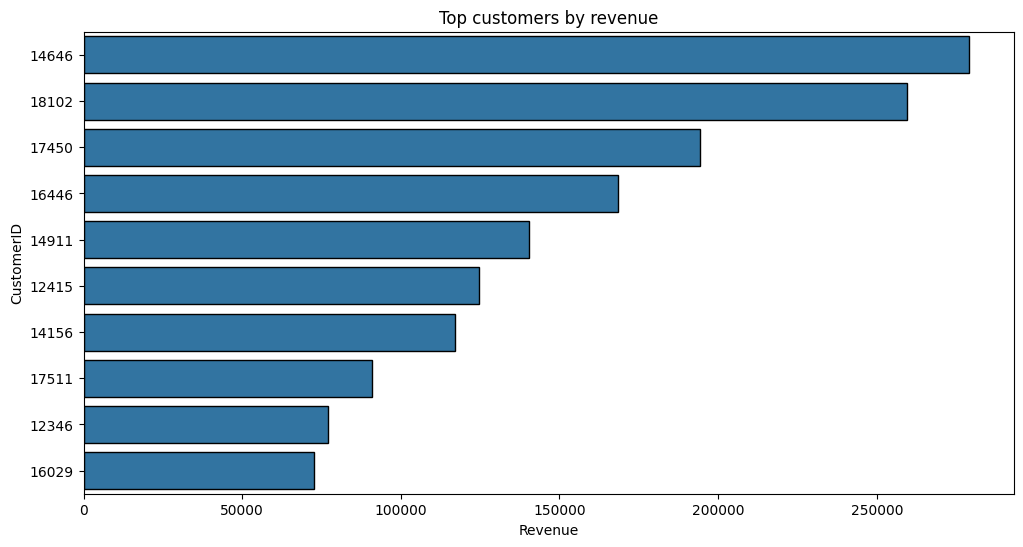

In [117]:
top_customers = data.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_customers.values, y=top_customers.index)
plt.title("Top customers by revenue")
plt.xlabel("Revenue")
plt.ylabel("CustomerID")
plt.show()

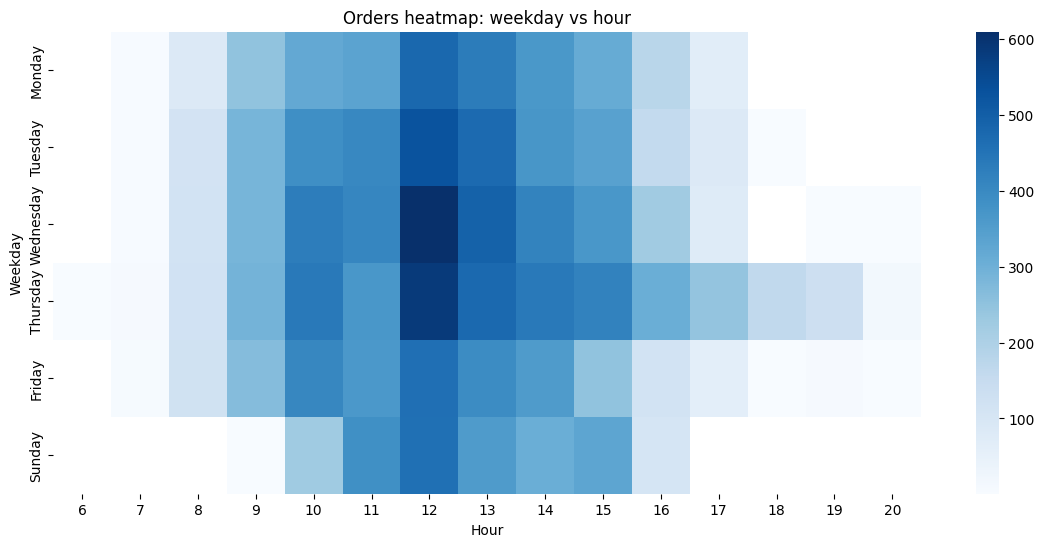

In [118]:
heatmap_data = data.pivot_table(
    index="Weekday",
    columns="Hour",
    values="InvoiceNo",
    aggfunc="nunique",
)
heatmap_data = heatmap_data.reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Sunday"])
plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="Blues")
plt.title("Orders heatmap: weekday vs hour")
plt.show()

In [119]:
# Cohort Retention Analysis
data["InvoiceMonth"] = data["InvoiceDate"].dt.to_period("M")
cohort = data.groupby("CustomerID")["InvoiceMonth"].min()
data["CohortMonth"] = data["CustomerID"].map(cohort)
data["CohortIndex"] = (
    (data["InvoiceMonth"].dt.year - data["CohortMonth"].dt.year) * 12
    + (data["InvoiceMonth"].dt.month - data["CohortMonth"].dt.month)
)
cohort_data = data.groupby(["CohortMonth", "CohortIndex"])["CustomerID"].nunique().reset_index()
cohort_counts = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="CustomerID")
retention = cohort_counts.divide(cohort_counts.iloc[:, 0], axis=0)

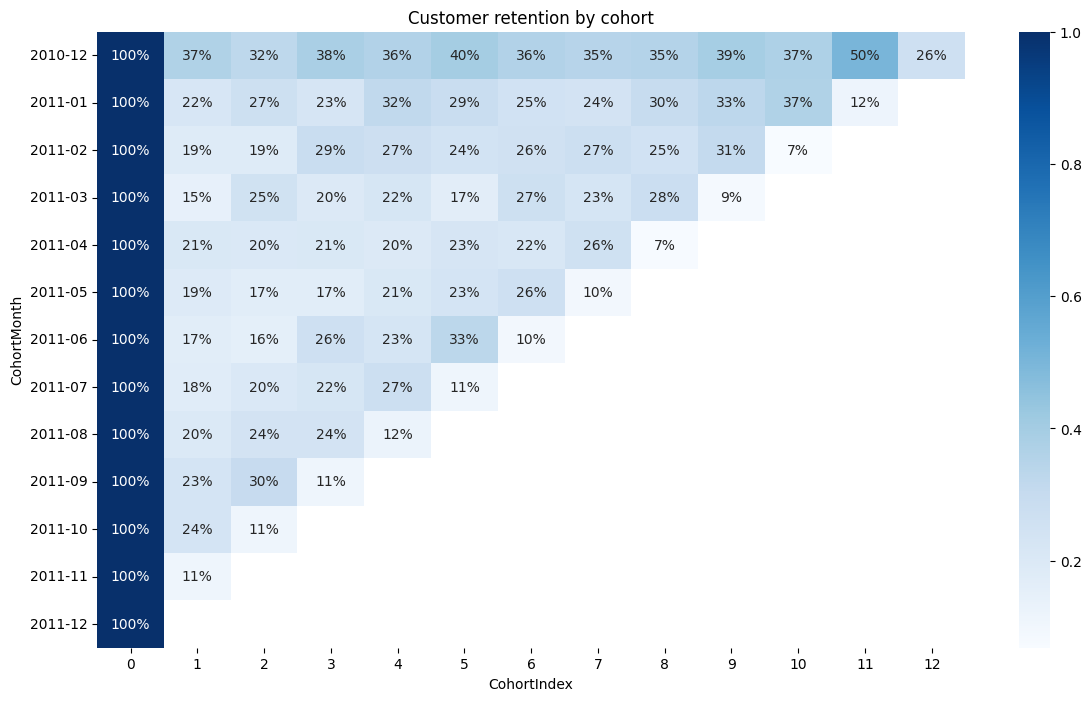

In [120]:
plt.figure(figsize=(14, 8))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
plt.title("Customer retention by cohort")
plt.show()

Retention heatmap показывает, что после первой покупки компания удерживает примерно 15–40% клиентов в последующие месяцы.

Наиболее высокий retention наблюдается у ранних групп клиентов, особенно у покупателей конца 2010 — начала 2011 года, что может говорить о наличии более лояльной базы постоянных покупателей.

При этом для большинства групп заметно постепенное снижение доли возвращающихся клиентов с течением времени, что является типичным поведением для e-commerce бизнеса.

Полученные результаты подтверждают необходимость дальнейшей сегментации клиентов и построения стратегий удержания для различных групп покупателей.

# RFM Feature Engineering

Для сегментации клиентов необходимо сформировать агрегированные пользовательские признаки.

В качестве основной методологии используется RFM-анализ:

- Recency — сколько дней прошло с последней покупки
- Frequency — количество уникальных заказов
- Monetary — общая сумма покупок клиента

Дополнительно будут рассчитаны расширенные клиентские признаки для более качественной кластеризации.

Небольшая группа клиентов генерирует существенно большую часть выручки компании.

Лидеры по объёму покупок значительно превосходят остальных клиентов, что указывает на наличие VIP / wholesale-сегмента.

Подобное распределение характерно для e-commerce: основная прибыль формируется ограниченным числом наиболее активных покупателей.

In [121]:
snapshot_date = data["InvoiceDate"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [122]:
rfm = data.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum",
})
rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1437.24
12349,19,1,1457.55
12350,310,1,294.40


In [123]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4334.0,92.703046,100.177047,1.00,18.000,51.00,143.0000,374.00
Frequency,4334.0,4.246654,7.642535,1.00,1.000,2.00,5.0000,206.00
Monetary,4334.0,2017.515838,8920.363571,3.75,304.305,663.71,1631.6225,279138.02


### RFM observations

RFM-признаки имеют сильную асимметрию распределений.

Большинство клиентов совершают небольшое количество заказов и имеют относительно низкий объём покупок, однако в данных присутствует группа extremely high-value customers с очень высокой частотой заказов и крупными суммами покупок.

Подобные выбросы могут негативно влиять на работу алгоритмов кластеризации, особенно KMeans, поэтому далее потребуется дополнительная обработка распределений и удаление extreme outliers.

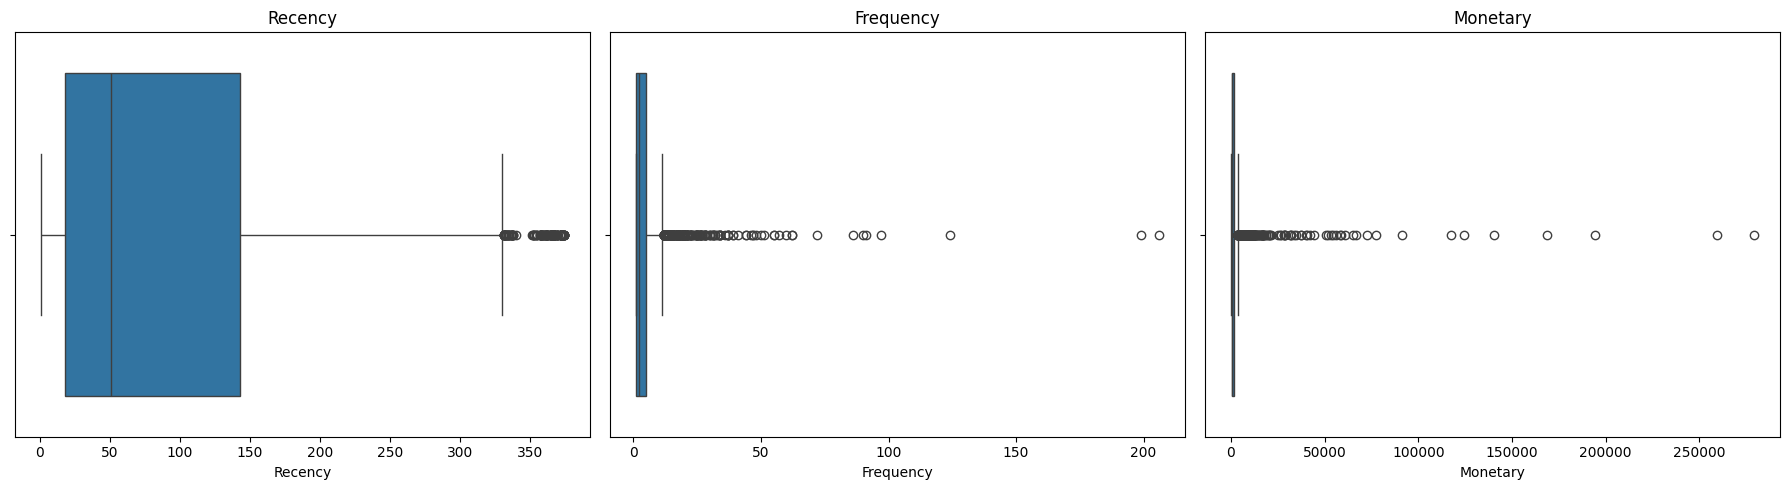

In [124]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x=rfm["Recency"], ax=axes[0])
axes[0].set_title("Recency")
sns.boxplot(x=rfm["Frequency"], ax=axes[1])
axes[1].set_title("Frequency")
sns.boxplot(x=rfm["Monetary"], ax=axes[2])
axes[2].set_title("Monetary")
plt.tight_layout()
plt.show()

### Outlier analysis

Boxplots подтверждают наличие extreme outliers в признаках Frequency и Monetary.

Основная масса клиентов сосредоточена в нижней части распределения, тогда как небольшое количество наблюдений имеет значительно более высокие значения.

Для distance-based алгоритмов кластеризации такие наблюдения могут доминировать при вычислении расстояний между объектами и приводить к нестабильному формированию кластеров.

Для повышения устойчивости моделей далее будет выполнено ограничение extreme values по 95-му перцентилю.

In [125]:
# пороги по 95 перцентилю
freq_limit = rfm["Frequency"].quantile(0.95)
monetary_limit = rfm["Monetary"].quantile(0.95)
print(freq_limit, monetary_limit)

13.0 5735.215499999997


In [126]:
# размер данных до удаления выбросов
print(f"Before outliers removing: {rfm.shape}")
# удаление extreme outliers
rfm = rfm[(rfm["Frequency"] <= freq_limit) & (rfm["Monetary"] <= monetary_limit)]
# размер данных после удаления выбросов
print(f"After outliers removing: {rfm.shape}")

Before outliers removing: (4334, 3)
After outliers removing: (4044, 3)


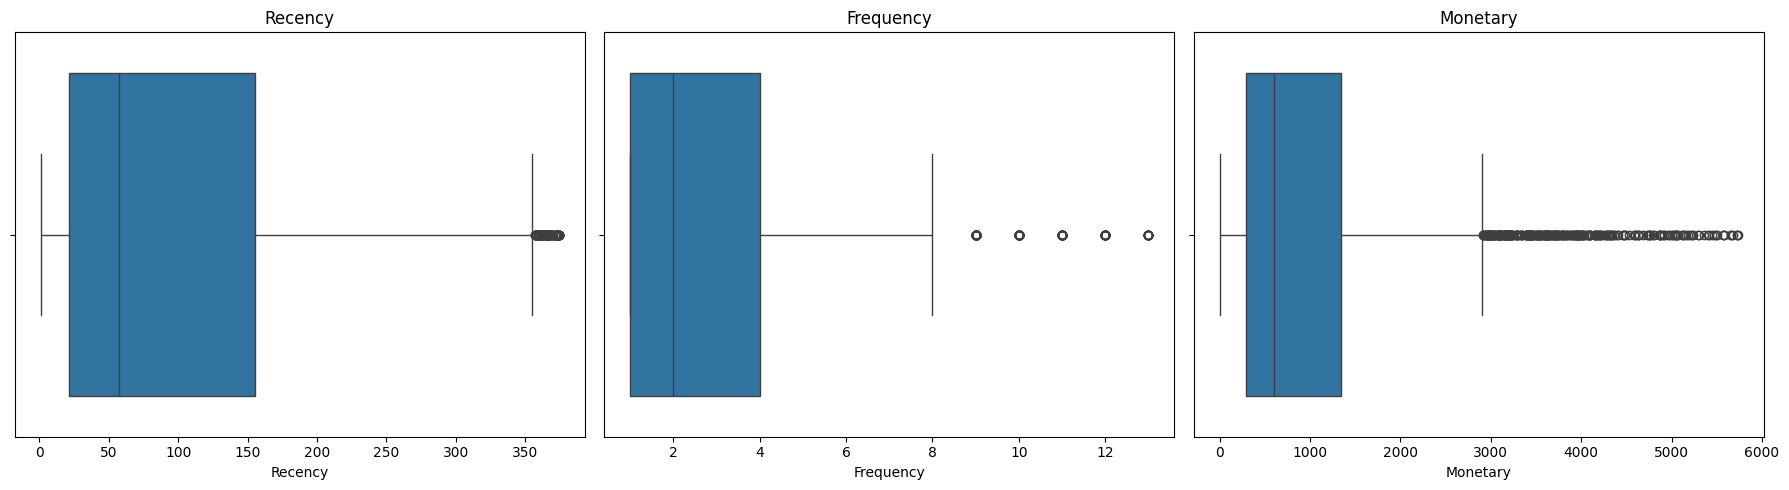

In [127]:
# распределения RFM-признаков после удаления выбросов
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x=rfm["Recency"], ax=axes[0])
axes[0].set_title("Recency")
sns.boxplot(x=rfm["Frequency"], ax=axes[1])
axes[1].set_title("Frequency")
sns.boxplot(x=rfm["Monetary"], ax=axes[2])
axes[2].set_title("Monetary")
plt.tight_layout()
plt.show()

После удаления extreme outliers распределения Frequency и Monetary стали заметно более стабильными и менее чувствительными к аномальным клиентам.

Основная структура данных сохранилась, однако влияние наиболее экстремальных наблюдений было снижено, что должно положительно повлиять на качество дальнейшей кластеризации.

## Log Transformation

Даже после удаления extreme outliers распределения Frequency и Monetary остаются сильно асимметричными.

Для уменьшения skewness и стабилизации распределений применим logarithmic transformation.

Это особенно важно для distance-based алгоритмов кластеризации, таких как KMeans.

In [128]:
# копия RFM-таблицы
rfm_log = rfm.copy()
# log-преобразованиег
rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])
rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347,1.098612,2.079442,8.368925
12348,4.330733,1.609438,7.271175
12349,2.995732,0.693147,7.285198
12350,5.739793,0.693147,5.688330
12352,3.610918,2.079442,7.234711


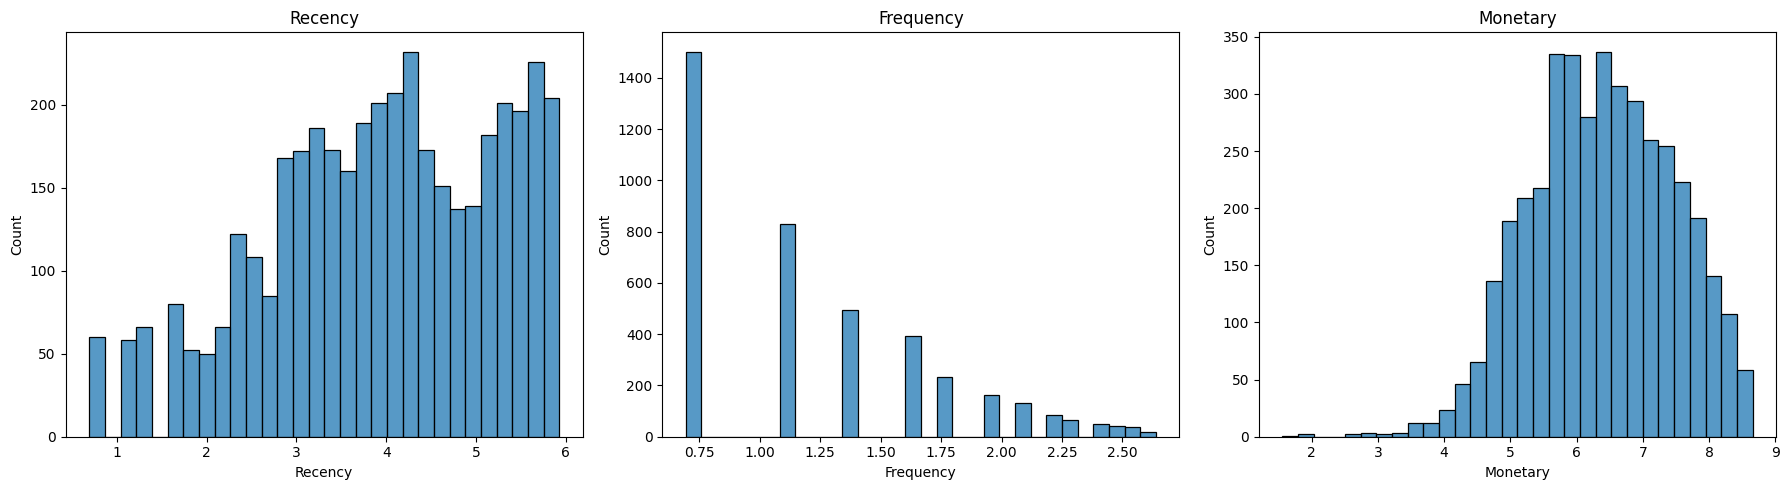

In [129]:
# распределения после log transformation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(rfm_log["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Recency")
sns.histplot(rfm_log["Frequency"], bins=30, ax=axes[1])
axes[1].set_title("Frequency")
sns.histplot(rfm_log["Monetary"], bins=30, ax=axes[2])
axes[2].set_title("Monetary")
plt.tight_layout()
plt.show()

Log transformation значительно уменьшила асимметрию распределений.

Признак Monetary стал близок к нормальному распределению, а Frequency получил более стабильный диапазон значений.

Подобная трансформация снижает влияние крупных значений на вычисление расстояний между объектами и делает данные более подходящими для алгоритмов кластеризации.

## Feature Scaling

Перед кластеризацией необходимо привести признаки к единому масштабу.

Алгоритмы кластеризации, основанные на расстояниях между объектами, чувствительны к диапазонам признаков. Без масштабирования признаки с большими значениями могут доминировать при вычислении дистанций.

Для нормализации распределений применим StandardScaler.

In [130]:
# scaler initialization
scaler = StandardScaler()
# масштабирование признаков
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled[:5]

array([[-2.21466578,  1.58211508,  1.85796219],
       [ 0.30207438,  0.70439731,  0.82557001],
       [-0.73744448, -1.00674834,  0.83875778],
       [ 1.39926002, -1.00674834, -0.66303597],
       [-0.25842084,  1.58211508,  0.79127655]])

In [131]:
rfm_scaled = pd.DataFrame(rfm_scaled, columns=rfm_log.columns, index=rfm_log.index)
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347,-2.214666,1.582115,1.857962
12348,0.302074,0.704397,0.825570
12349,-0.737444,-1.006748,0.838758
12350,1.399260,-1.006748,-0.663036
12352,-0.258421,1.582115,0.791277


После scaling все признаки были приведены к сопоставимому масштабу.

Теперь данные готовы для применения алгоритмов кластеризации и построения GPU-based ML pipeline.

# GPU CLUSTERING

### RAPIDS KMeans

In [132]:
# pandas -> cuDF
rfm_gpu = cudf.DataFrame.from_pandas(rfm_scaled)
rfm_gpu.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347,-2.214666,1.582115,1.857962
12348,0.302074,0.704397,0.825570
12349,-0.737444,-1.006748,0.838758
12350,1.399260,-1.006748,-0.663036
12352,-0.258421,1.582115,0.791277


In [133]:
# RAPIDS KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
# обучение модели
kmeans.fit(rfm_gpu)
# предсказание кластеров
clusters = kmeans.predict(rfm_gpu)
clusters[:10]

0    2
1    0
2    1
3    3
4    2
5    3
6    0
7    3
8    2
9    1
dtype: int32

In [134]:
# переводим clusters в cupy array
rfm_gpu["Cluster"] = clusters.values
rfm_gpu.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347,-2.214666,1.582115,1.857962,2
12348,0.302074,0.704397,0.825570,0
12349,-0.737444,-1.006748,0.838758,1
12350,1.399260,-1.006748,-0.663036,3
12352,-0.258421,1.582115,0.791277,2


In [135]:
rfm_gpu["Cluster"].value_counts()

Cluster
3    1247
0    1079
2     929
1     789
Name: count, dtype: int64

In [136]:
# elbow method
K_range = range(2, 11)  
inertias = []

for k in K_range: 
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_gpu)
    try:
        inertias.append(model.inertia_)
    except AttributeError:
        inertias.append(model.inertia)

    del model

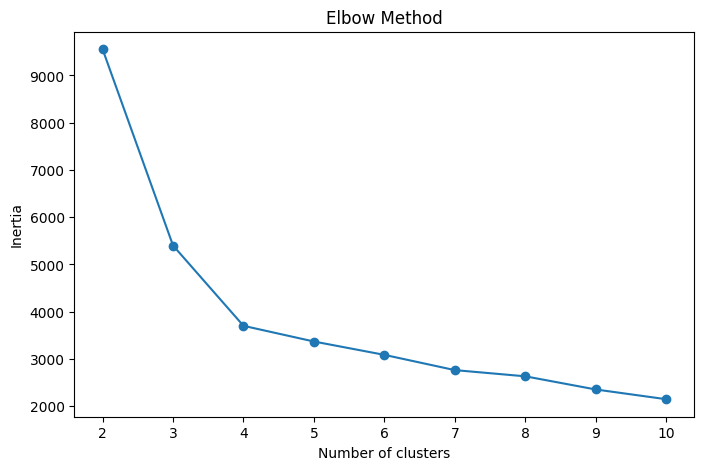

In [137]:
# график elbow method
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

### Elbow Method Observations

График Elbow Method показывает резкое снижение inertia от 2 до 4 кластеров.

После k=4 скорость уменьшения inertia заметно снижается, а дальнейшее увеличение количества кластеров даёт менее значительное улучшение.

Это указывает на то, что k=4 является хорошим выбором для сегментации клиентов.

In [138]:
# silhouette score на GPU
silhouette = cython_silhouette_score(cp.asarray(rfm_scaled), clusters)
print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.3318


### Silhouette Score Observations

Полученное значение Silhouette Score = 0.3318 указывает на удовлетворительное качество кластеризации.

Кластеры имеют достаточно хорошее разделение, однако между некоторыми группами клиентов сохраняется частичное пересечение, что типично для реальных e-commerce данных.

Результат подтверждает, что модель KMeans с k=4 подходит для baseline customer segmentation.

In [139]:
# UMAP reduction
umap_model = UMAP(n_components=2, random_state=42)
umap_embeddings = umap_model.fit_transform(rfm_gpu)
umap_embeddings[:5]

[2026-05-20 16:09:42.343] [CUML] [info] build_algo set to brute_force_knn because random_state is given


,0,1
CustomerID,,
12347,-0.401365,15.348545
12348,6.900295,-3.669832
12349,-0.343409,-17.108120
12350,-9.656673,3.369555
12352,-4.484058,15.284988


In [140]:
# UMAP -> pandas
umap_df = umap_embeddings.to_pandas()
umap_df.columns = ["UMAP1", "UMAP2"]
umap_df["Cluster"] = cp.asnumpy(clusters)
umap_df.head()

,UMAP1,UMAP2,Cluster
CustomerID,,,
12347,-0.401365,15.348545,2
12348,6.900295,-3.669832,0
12349,-0.343409,-17.108120,1
12350,-9.656673,3.369555,3
12352,-4.484058,15.284988,2


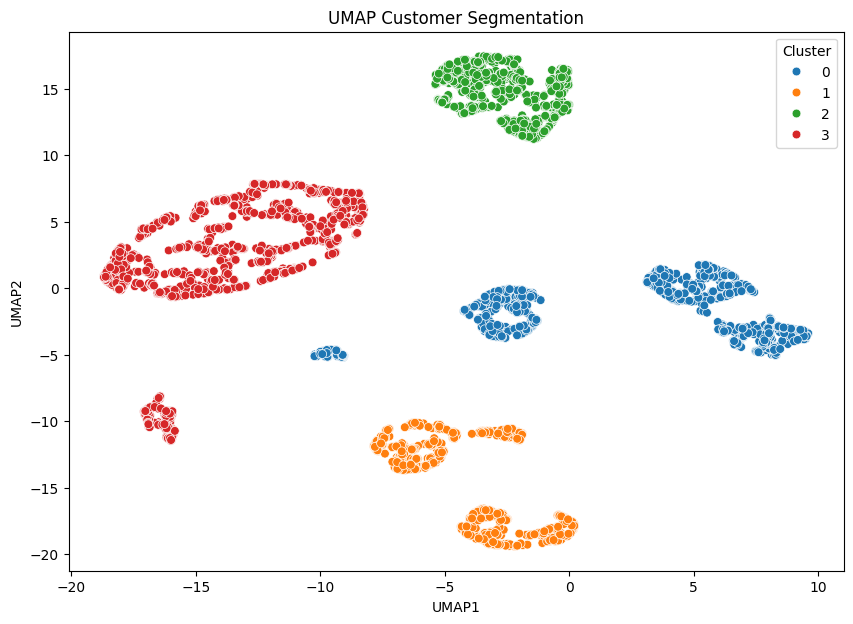

In [141]:
# визуализация кластеров
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="Cluster",
    palette="tab10",
    s=40,
)
plt.title("UMAP Customer Segmentation")
plt.show()

In [142]:
# обратно в pandas
rfm_final = rfm.copy()
rfm_final["Cluster"] = cp.asnumpy(clusters)
rfm_final.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347,2,7,4310.00,2
12348,75,4,1437.24,0
12349,19,1,1457.55,1
12350,310,1,294.40,3
12352,36,7,1385.74,2


In [143]:
# средние значения по кластерам
cluster_summary = rfm_final.groupby("Cluster").mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,101.128823,2.966636,1161.627110
1,23.311787,1.718631,420.118897
2,19.847147,6.646932,2279.175877
3,200.396151,1.172414,269.143898


In [144]:
# бизнес-названия сегментов
cluster_names = {
    0: "Potential Churn",
    1: "New Customers",
    2: "VIP Customers",
    3: "Low Value Customers"
}

# добавляем названия сегментов
rfm_final["Segment"] = rfm_final["Cluster"].map(cluster_names)

rfm_final[["Cluster", "Segment"]].head()

,Cluster,Segment
CustomerID,,
12347,2,VIP Customers
12348,0,Potential Churn
12349,1,New Customers
12350,3,Low Value Customers
12352,2,VIP Customers


## Интерпретация кластеров

Кластеры были преобразованы в бизнес-сегменты на основе:
- активности клиентов;
- частоты покупок;
- общего объема покупок.

Это делает результаты кластеризации более понятными и полезными для маркетинговых и retention-стратегий.

In [145]:
# размер кластеров
rfm_final["Cluster"].value_counts()

Cluster
3    1247
0    1079
2     929
1     789
Name: count, dtype: int64

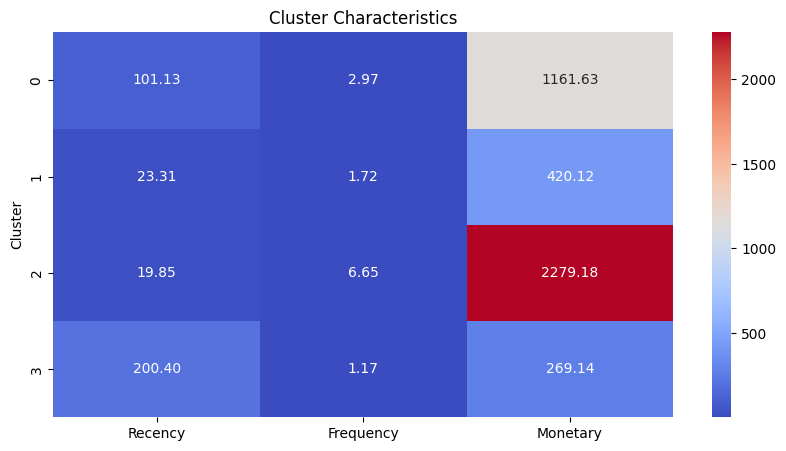

In [146]:
# heatmap кластеров
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_summary, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Cluster Characteristics")
plt.show()

выполнена сегментация клиентов интернет-магазина с помощью RAPIDS GPU и алгоритма KMeans.

Были построены RFM-признаки:
- Recency
- Frequency
- Monetary

После очистки данных и масштабирования модель выделила 4 клиентских сегмента.

## Основные сегменты

- Cluster 2 — VIP Customers  
  Высокая частота покупок и высокий общий объем трат.

- Cluster 0 — Potential Churn  
  Клиенты с высокой давностью последней покупки и риском оттока.

- Cluster 1 — New Customers  
  Недавно активные клиенты с небольшим количеством заказов.

- Cluster 3 — Low Value Customers  
  Клиенты с низкой активностью и низким уровнем покупок.

Качество кластеризации:
- `Silhouette Score = 0.3295`

UMAP-визуализация показала хорошее разделение кластеров


### RAPIDS DBSCAN

In [147]:
# RAPIDS DBSCAN
dbscan = DBSCAN(eps=0.7, min_samples=15)
dbscan_labels = dbscan.fit_predict(rfm_gpu)
dbscan_labels[:10]

CustomerID
12347    0
12348    1
12349    5
12350    2
12352    0
12353    2
12354    3
12355    2
12356    0
12358    4
dtype: int32

In [148]:
# labels -> pandas
rfm_dbscan = rfm.copy()
rfm_dbscan["Cluster"] = cp.asnumpy(dbscan_labels)
rfm_dbscan.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347,2,7,4310.00,0
12348,75,4,1437.24,1
12349,19,1,1457.55,5
12350,310,1,294.40,2
12352,36,7,1385.74,0


In [149]:
# распределение кластеров
rfm_dbscan["Cluster"].value_counts()

Cluster
 2    1052
 1     989
 0     928
 4     429
 5     354
 6     191
 3      89
-1      12
Name: count, dtype: int64

In [150]:
# удаляем noise points
dbscan_filtered = rfm_dbscan[rfm_dbscan["Cluster"] != -1]

In [151]:
# silhouette score на GPU
dbscan_score = cython_silhouette_score(
    cp.asarray(dbscan_filtered[["Recency", "Frequency", "Monetary"]].values),
    cp.asarray(dbscan_filtered["Cluster"].values),
)

print(f"DBSCAN Silhouette Score: {dbscan_score:.4f}")

DBSCAN Silhouette Score: -0.1308


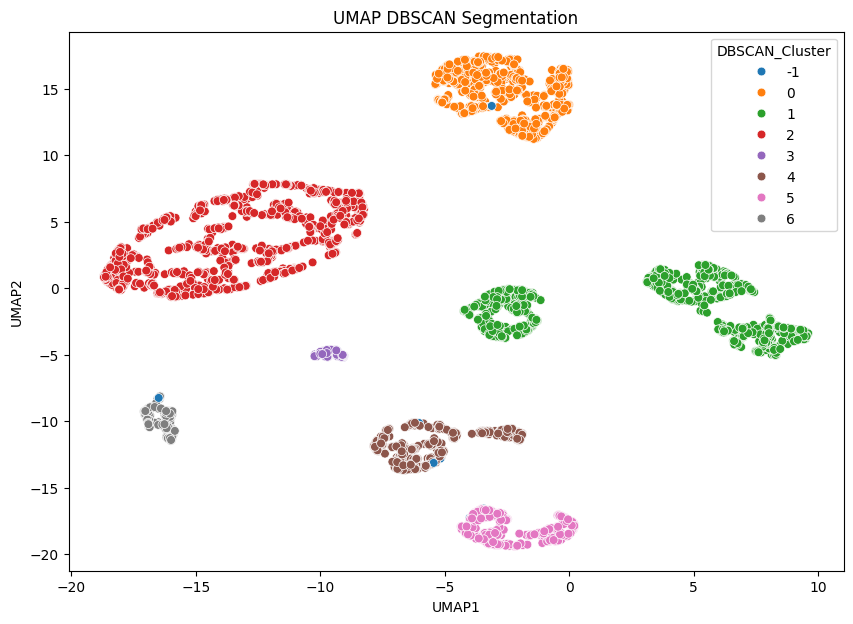

In [152]:
# UMAP для визуализации DBSCAN
# переводим GPU labels в numpy
umap_df["DBSCAN_Cluster"] = dbscan_labels.to_numpy()

# визуализация кластеров DBSCAN
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="DBSCAN_Cluster",
    palette="tab10",
    s=40,
)

plt.title("UMAP DBSCAN Segmentation")
plt.show()

## DBSCAN Results

DBSCAN показал низкое качество кластеризации:
- `Silhouette Score = - 0.1308`

Алгоритм создал слишком много небольших кластеров и noise points.

По сравнению с KMeans:
- clusters менее стабильны
- сегменты хуже разделены
- интерпретация сложнее

### Вывод
Для данного RFM dataset KMeans показывает более качественную и устойчивую сегментацию клиентов.

### RAPIDS HDBSCAN

In [153]:
# RAPIDS HDBSCAN
hdbscan = HDBSCAN(min_cluster_size=50, min_samples=10)
hdbscan_labels = hdbscan.fit_predict(rfm_gpu)
hdbscan_labels[:10]

CustomerID
12347    0
12348    9
12349   -1
12350    4
12352    0
12353    4
12354    3
12355    4
12356    0
12358    7
dtype: int32

In [154]:
# labels -> pandas
rfm_hdbscan = rfm.copy()
rfm_hdbscan["Cluster"] = cp.asnumpy(hdbscan_labels)
rfm_hdbscan.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347,2,7,4310.00,0
12348,75,4,1437.24,9
12349,19,1,1457.55,-1
12350,310,1,294.40,4
12352,36,7,1385.74,0


In [155]:
# распределение кластеров
rfm_hdbscan["Cluster"].value_counts()

Cluster
 4    1045
 0     929
 2     351
 8     330
 5     328
 7     304
 9     269
 1     190
-1     116
 6      95
 3      87
Name: count, dtype: int64

In [156]:
# удаляем noise points
hdbscan_filtered = rfm_hdbscan[rfm_hdbscan["Cluster"] != -1]

In [157]:
# silhouette score
hdbscan_score = cython_silhouette_score(
    cp.asarray(hdbscan_filtered[["Recency", "Frequency", "Monetary"]].values),
    cp.asarray(hdbscan_filtered["Cluster"].values),
)
print(f"HDBSCAN Silhouette Score: {hdbscan_score:.4f}")

HDBSCAN Silhouette Score: -0.1646


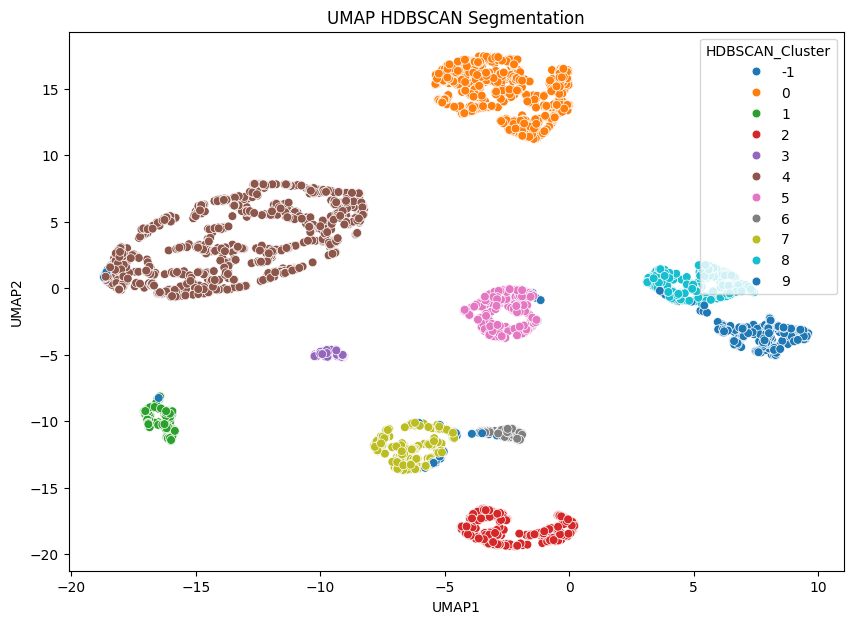

In [158]:
# UMAP для визуализации HDBSCAN
# переводим GPU labels в numpy
umap_df["HDBSCAN_Cluster"] = hdbscan_labels.to_numpy()

# визуализация кластеров HDBSCAN
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="HDBSCAN_Cluster",
    palette="tab10",
    s=40,
)

plt.title("UMAP HDBSCAN Segmentation")
plt.show()

## HDBSCAN Results

HDBSCAN также показал низкое качество кластеризации:
- `HDBSCAN Silhouette Score: -0.1646`

Алгоритм создал большое количество небольших кластеров и noise observations.

По сравнению с:
- KMeans → HDBSCAN показал худшую разделимость сегментов
- DBSCAN → результаты сопоставимы, но также нестабильны

### Вывод
Для данного RFM dataset алгоритмы density-based clustering оказались менее эффективны.

KMeans показал:
- более устойчивые сегменты
- лучшую интерпретируемость
- более высокий silhouette score

Поэтому KMeans был выбран как финальная модель сегментации клиентов.

# Сравнение моделей

| Модель | Silhouette Score | Результат |
|---|---|---|
| KMeans | 0.3318 | Лучшая кластеризация |
| DBSCAN |  -0.1308 | Плохое разделение кластеров |
| HDBSCAN | -0.1646 | Слишком много мелких кластеров |

# Итоговый вывод

KMeans показал лучший результат для сегментации клиентов на основе RFM-признаков.

Преимущества KMeans:
- стабильные кластеры
- хорошее разделение клиентов
- лучший silhouette score
- простая бизнес-интерпретация

DBSCAN и HDBSCAN сформировали слишком фрагментированные кластеры и показали низкое качество кластеризации.

Финальная выбранная модель:
- RAPIDS GPU KMeans
- количество кластеров = 4

Проект успешно продемонстрировал GPU-ускоренную сегментацию клиентов с использованием RAPIDS на RTX 3090.

# Extended Feature Engineering

In [159]:
# средний размер корзины
basket_size = data.groupby(["CustomerID", "InvoiceNo"])["TotalPrice"].sum().reset_index()
basket_size.head()

,CustomerID,InvoiceNo,TotalPrice
0,12346,541431,77183.60
1,12347,537626,711.79
2,12347,542237,475.39
3,12347,549222,636.25
4,12347,556201,382.52


In [160]:
# средний чек клиента
avg_basket = basket_size.groupby("CustomerID")["TotalPrice"].mean()
avg_basket.head()

CustomerID
12346    77183.600000
12347      615.714286
12348      359.310000
12349     1457.550000
12350      294.400000
Name: TotalPrice, dtype: float64

In [161]:
# средний размер корзины клиента
basket_size = data.groupby(["CustomerID", "InvoiceNo"])["TotalPrice"].sum().reset_index()
avg_basket = basket_size.groupby("CustomerID")["TotalPrice"].mean()
avg_basket.head()

CustomerID
12346    77183.600000
12347      615.714286
12348      359.310000
12349     1457.550000
12350      294.400000
Name: TotalPrice, dtype: float64

In [162]:
# добавляем признак в rfm
rfm["AvgBasketSize"] = data.groupby("CustomerID")["Quantity"].mean().reindex(rfm.index)
rfm.head()

,Recency,Frequency,Monetary,AvgBasketSize
CustomerID,,,,
12347,2,7,4310.00,13.505495
12348,75,4,1437.24,86.370370
12349,19,1,1457.55,8.750000
12350,310,1,294.40,12.250000
12352,36,7,1385.74,6.831169


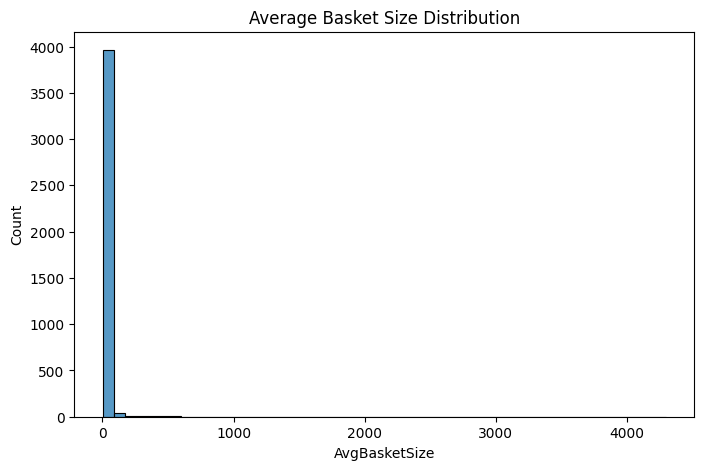

In [163]:
# распределение признака
plt.figure(figsize=(8, 5))
sns.histplot(rfm["AvgBasketSize"], bins=50)
plt.title("Average Basket Size Distribution")
plt.show()

### Avg Basket Size

Признак Average Basket Size отражает средний размер заказа клиента.

Он позволяет дополнительно учитывать покупательское поведение и потенциальную ценность клиента помимо классических RFM-признаков.

In [164]:
# количество уникальных товаров
unique_products = data.groupby("CustomerID")["StockCode"].nunique()
unique_products.head()

CustomerID
12346      1
12347    103
12348     21
12349     72
12350     16
Name: StockCode, dtype: int64

In [165]:
# добавляем признак в rfm
rfm["UniqueProducts"] = data.groupby("CustomerID")["StockCode"].nunique().reindex(rfm.index)
rfm.head()

,Recency,Frequency,Monetary,AvgBasketSize,UniqueProducts
CustomerID,,,,,
12347,2,7,4310.00,13.505495,103
12348,75,4,1437.24,86.370370,21
12349,19,1,1457.55,8.750000,72
12350,310,1,294.40,12.250000,16
12352,36,7,1385.74,6.831169,57


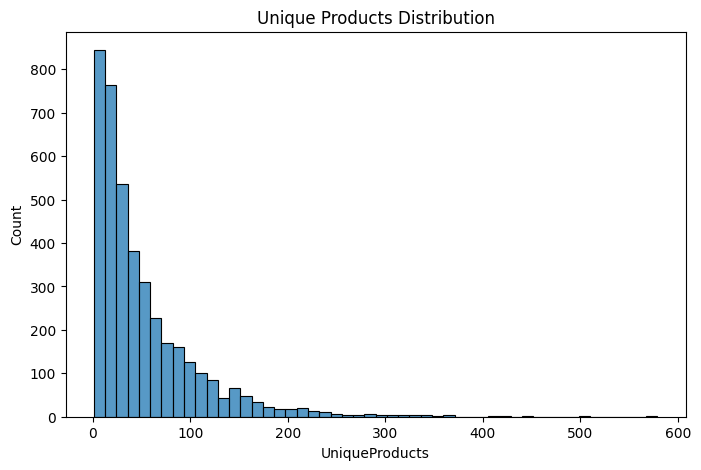

In [166]:
# распределение признака
plt.figure(figsize=(8, 5))
sns.histplot(rfm["UniqueProducts"], bins=50)
plt.title("Unique Products Distribution")
plt.show()

### Unique Products

Признак Unique Products показывает разнообразие товаров, приобретаемых клиентом.

Высокие значения могут указывать на более вовлечённых клиентов с широким потребительским поведением.

Тюнингуем с новыми признаками 

In [167]:
# новые признаки
features = ["Recency", "Frequency", "Monetary", "AvgBasketSize", "UniqueProducts"]
rfm_features = rfm[features]
rfm_features.head()

,Recency,Frequency,Monetary,AvgBasketSize,UniqueProducts
CustomerID,,,,,
12347,2,7,4310.00,13.505495,103
12348,75,4,1437.24,86.370370,21
12349,19,1,1457.55,8.750000,72
12350,310,1,294.40,12.250000,16
12352,36,7,1385.74,6.831169,57


In [168]:
# pipeline для preprocessing
preprocessing_pipeline = Pipeline([
    ("log_transform", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])

# preprocessing данных
rfm_scaled_v2 = preprocessing_pipeline.fit_transform(rfm_features)

rfm_scaled_v2[:5]

array([[-2.21466578,  1.58211508,  1.85796219,  0.34846368,  1.10143201],
       [ 0.30207438,  0.70439731,  0.82557001,  2.57813989, -0.34000055],
       [-0.73744448, -1.00674834,  0.83875778, -0.14482409,  0.77300066],
       [ 1.39926002, -1.00674834, -0.66303597,  0.23605041, -0.57925355],
       [-0.25842084,  1.58211508,  0.79127655, -0.41695486,  0.55955649]])

In [169]:
# pandas -> cudf
rfm_gpu_v2 = cudf.DataFrame.from_pandas(pd.DataFrame(rfm_scaled_v2, columns=features))
rfm_gpu_v2.head()

,Recency,Frequency,Monetary,AvgBasketSize,UniqueProducts
0,-2.214666,1.582115,1.857962,0.348464,1.101432
1,0.302074,0.704397,0.825570,2.578140,-0.340001
2,-0.737444,-1.006748,0.838758,-0.144824,0.773001
3,1.399260,-1.006748,-0.663036,0.236050,-0.579254
4,-0.258421,1.582115,0.791277,-0.416955,0.559556


In [170]:
# KMeans v2
kmeans_v2 = KMeans(n_clusters=4, random_state=42)
clusters_v2 = kmeans_v2.fit_predict(rfm_gpu_v2)
clusters_v2[:10]

0    1
1    3
2    2
3    0
4    1
5    0
6    2
7    0
8    1
9    2
dtype: int32

In [171]:
# silhouette score на GPU
score_v2 = cython_silhouette_score(cp.asarray(rfm_scaled_v2), clusters_v2)
print(f"Extended Features Silhouette Score: {score_v2:.4f}")

Extended Features Silhouette Score: 0.2364


In [172]:
# UMAP embedding
umap_model = UMAP(n_components=2, random_state=42)

umap_result_v2 = umap_model.fit_transform(rfm_scaled_v2)

[2026-05-20 16:09:45.002] [CUML] [info] build_algo set to brute_force_knn because random_state is given


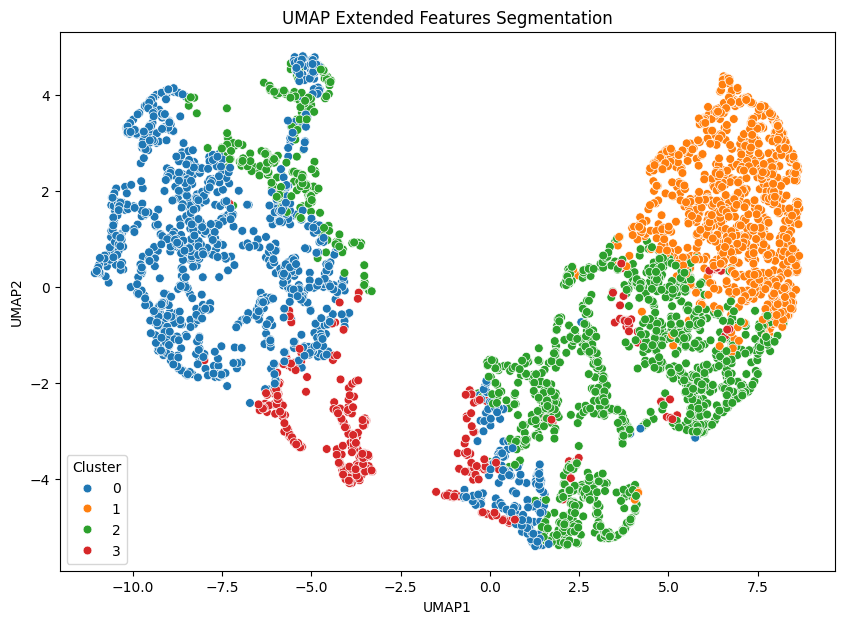

In [173]:
# dataframe для визуализации сегментов
umap_v2_df = pd.DataFrame({
    "UMAP1": umap_result_v2[:, 0],
    "UMAP2": umap_result_v2[:, 1],
    "Cluster": cp.asnumpy(clusters_v2)
})

# визуализация кластеров
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=umap_v2_df,
    x="UMAP1",
    y="UMAP2",
    hue="Cluster",
    palette="tab10",
    s=40,
)

plt.title("UMAP Extended Features Segmentation")
plt.show()

# Baseline vs Extended Features

| Feature Set | Silhouette Score |
|---|---|
| Baseline RFM | 0.3318 |
| Extended Features | 0.2364 |

Добавление признаков:
- AvgBasketSize
- UniqueProducts

не улучшило качество кластеризации.

После расширения feature space разделение клиентов стало менее выраженным, а silhouette score снизился.

## Вывод

Классические RFM-признаки показали лучшую эффективность для текущей задачи customer segmentation.

Поэтому baseline RFM был выбран как финальный feature set проекта.

# Production Pipeline for Final Model

In [174]:
#  финальный pipeline для кластеризации
final_pipeline = Pipeline([
    ("log_transform", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(
        n_clusters=4,
        random_state=42
    ))
])

In [175]:
# обучение финального pipeline
rfm_base = rfm[["Recency", "Frequency", "Monetary"]]
final_pipeline.fit(rfm_base)

In [176]:
# предсказание кластеров и добавление в итоговую таблицу
rfm_final["Cluster"] = final_pipeline.predict(rfm_base)

In [177]:
# сохранение финального pipeline
joblib.dump(final_pipeline, "../outputs/models/final_pipeline.pkl")

['../outputs/models/final_pipeline.pkl']

In [178]:
# проверка сохранения
print("Outputs:", os.listdir("../outputs"))
print("Models:", os.listdir("../outputs/models"))

Outputs: ['models']
Models: ['final_pipeline.pkl']


# Финальный вывод

В проекте была построена GPU-ускоренная система сегментации клиентов интернет-магазина с использованием RAPIDS ecosystem и алгоритмов кластеризации.

В ходе работы были:
- очищены и подготовлены транзакционные данные;
- построены RFM-признаки;
- реализован preprocessing pipeline;
- протестированы алгоритмы KMeans, DBSCAN и HDBSCAN;
- выполнена UMAP-визуализация клиентских сегментов;
- реализован inference pipeline для новых клиентов.

Лучший результат показала модель RAPIDS KMeans на базовых RFM-признаках:

- Silhouette Score: 0.3318
- 4 клиентских сегмента
- хорошее визуальное разделение кластеров

В результате были выделены:
- VIP Customers
- New Customers
- Potential Churn
- Low Value Customers

Полученные сегменты могут использоваться для:
- персонализированного маркетинга;
- retention-стратегий;
- customer analytics;
- рекомендательных систем.

Проект демонстрирует production-oriented подход к Customer Segmentation с использованием GPU Data Science и RAPIDS.